<a href="https://colab.research.google.com/github/contactyuvrajchand-droid/machine_learning_lab/blob/main/Week_9_Bitcoin_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1. Setting the Environment

In [ ]:
# Install PySpark in the Google Colab runtime.
!pip -q install pyspark

import os
import re
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

from pyspark.sql import SparkSession, Window
from pyspark.sql.functions import (
    col, lit, when, coalesce, to_timestamp, from_unixtime, to_date,
    lag, lead, avg, stddev, row_number, month, dayofweek, sin, cos,
    min as spark_min, max as spark_max, sum as spark_sum,
    min_by, max_by
)
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

print("Setup complete.")

Setup complete.


## 2. Mount Google Drive and start Spark

The file path below matches the supplied Google Drive location exactly. Spark reads the CSV directly; Pandas is not used for loading the large one-minute dataset.

In [ ]:
# Mount Google Drive.
drive.mount('/content/drive')

# Exact dataset location supplied for this assessment.
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/lab9/btcusd_1-min_data.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH}\n"
        "Check the filename and make sure the file is inside MyDrive/Colab Notebooks/lab9/."
    )

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("CN7030_Bitcoin_Distributed_Forecasting")
    .config("spark.sql.session.timeZone", "UTC")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

print("Dataset found:", DATA_PATH)
print("Spark version:", spark.version)

Mounted at /content/drive
Dataset found: /content/drive/MyDrive/Colab Notebooks/lab9/btcusd_1-min_data.csv
Spark version: 4.0.3


## 3. Load and inspect the Bitcoin dataset

The CSV is initially read as strings, after which the required fields are explicitly cast. This avoids an expensive full-file schema-inference pass on the large one-minute dataset.

In [ ]:
# Load the CSV as a distributed Spark DataFrame.
raw_df = (
    spark.read
    .option("header", True)
    .option("mode", "PERMISSIVE")
    .csv(DATA_PATH)
)

print("Original columns:")
print(raw_df.columns)
raw_df.printSchema()
raw_df.show(5, truncate=False)

Original columns:
['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume']
root
 |-- Timestamp: string (nullable = true)
 |-- Open: string (nullable = true)
 |-- High: string (nullable = true)
 |-- Low: string (nullable = true)
 |-- Close: string (nullable = true)
 |-- Volume: string (nullable = true)

+----------+----+----+----+-----+------+
|Timestamp |Open|High|Low |Close|Volume|
+----------+----+----+----+-----+------+
|1325376060|4.58|4.58|4.58|4.58 |0.0   |
|1325376120|4.58|4.58|4.58|4.58 |0.0   |
|1325376180|4.58|4.58|4.58|4.58 |0.0   |
|1325376240|4.58|4.58|4.58|4.58 |0.0   |
|1325376300|4.58|4.58|4.58|4.58 |0.0   |
+----------+----+----+----+-----+------+
only showing top 5 rows


In [ ]:
# Normalise names such as Volume_(BTC) -> Volume_BTC and Weighted Price -> Weighted_Price.
for old_name in raw_df.columns:
    new_name = re.sub(r"[^A-Za-z0-9]+", "_", old_name).strip("_")
    if old_name != new_name:
        raw_df = raw_df.withColumnRenamed(old_name, new_name)

column_lookup = {name.lower(): name for name in raw_df.columns}

def find_column(*candidates, required=True):
    # Return the first matching normalised Spark column name.
    for candidate in candidates:
        match = column_lookup.get(candidate.lower())
        if match is not None:
            return match
    if required:
        raise ValueError(
            f"None of these required columns were found: {candidates}. "
            f"Available columns: {raw_df.columns}"
        )
    return None

timestamp_col = find_column("Timestamp", "Date", "Datetime", "Date_Time")
open_col = find_column("Open")
high_col = find_column("High")
low_col = find_column("Low")
close_col = find_column("Close")
volume_col = find_column("Volume_BTC", "Volume", "Volume_Currency")
weighted_col = find_column("Weighted_Price", "WeightedPrice", required=False)

print("Normalised columns:")
print(raw_df.columns)
print("Selected volume field:", volume_col)
print("Selected weighted-price field:", weighted_col or "Close (fallback)")

Normalised columns:
['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume']
Selected volume field: Volume
Selected weighted-price field: Close (fallback)


## 4. Preprocess and organise the data chronologically

The common Bitcoin Historical Data format stores `Timestamp` as Unix seconds. The conversion below also supports Unix milliseconds or a formatted timestamp. Missing/non-positive price values and invalid volume values are removed before chronological processing.

In [ ]:
# Convert Unix seconds/milliseconds or formatted timestamps into a Spark timestamp.
timestamp_number = col(timestamp_col).cast("double")
unix_seconds = when(
    timestamp_number > lit(1_000_000_000_000),
    timestamp_number / lit(1000.0)
).otherwise(timestamp_number)

event_time = coalesce(
    to_timestamp(from_unixtime(unix_seconds.cast("long"))),
    to_timestamp(col(timestamp_col), "yyyy-MM-dd HH:mm:ss"),
    to_timestamp(col(timestamp_col), "yyyy-MM-dd")
)

weighted_expression = (
    col(weighted_col).cast("double") if weighted_col is not None
    else col(close_col).cast("double")
)

bitcoin_df = raw_df.select(
    event_time.alias("EventTime"),
    col(open_col).cast("double").alias("Open"),
    col(high_col).cast("double").alias("High"),
    col(low_col).cast("double").alias("Low"),
    col(close_col).cast("double").alias("Close"),
    col(volume_col).cast("double").alias("Volume"),
    weighted_expression.alias("Weighted_Price")
)

required_fields = [
    "EventTime", "Open", "High", "Low", "Close", "Volume", "Weighted_Price"
]

clean_df = (
    bitcoin_df
    .dropna(subset=required_fields)       # drop nulls and NaN values
    .filter(
        (col("Open") > 0) &
        (col("High") > 0) &
        (col("Low") > 0) &
        (col("Close") > 0) &
        (col("Volume") >= 0)
    )
    .dropDuplicates(["EventTime"])
).cache()

valid_rows = clean_df.count()
print(f"Valid one-minute observations: {valid_rows:,}")
clean_df.orderBy("EventTime").show(10, truncate=False)

Valid one-minute observations: 7,679,564
+-------------------+----+----+----+-----+------+--------------+
|EventTime          |Open|High|Low |Close|Volume|Weighted_Price|
+-------------------+----+----+----+-----+------+--------------+
|2012-01-01 00:01:00|4.58|4.58|4.58|4.58 |0.0   |4.58          |
|2012-01-01 00:02:00|4.58|4.58|4.58|4.58 |0.0   |4.58          |
|2012-01-01 00:03:00|4.58|4.58|4.58|4.58 |0.0   |4.58          |
|2012-01-01 00:04:00|4.58|4.58|4.58|4.58 |0.0   |4.58          |
|2012-01-01 00:05:00|4.58|4.58|4.58|4.58 |0.0   |4.58          |
|2012-01-01 00:06:00|4.58|4.58|4.58|4.58 |0.0   |4.58          |
|2012-01-01 00:07:00|4.58|4.58|4.58|4.58 |0.0   |4.58          |
|2012-01-01 00:08:00|4.58|4.58|4.58|4.58 |0.0   |4.58          |
|2012-01-01 00:09:00|4.58|4.58|4.58|4.58 |0.0   |4.58          |
|2012-01-01 00:10:00|4.58|4.58|4.58|4.58 |0.0   |4.58          |
+-------------------+----+----+----+-----+------+--------------+
only showing top 10 rows


## 5. Create a daily Bitcoin time series

One-minute observations are aggregated with distributed Spark operations. For each UTC day:

- `Open` is the first observed price.
- `High` and `Low` are the daily extremes.
- `Close` is the final observed price.
- `Volume` is summed.
- `Weighted_Price` is volume-weighted.

This makes the supervised forecasting task easy to interpret: use information available through day *t* to predict the closing price on day *t + 1*.

In [ ]:
daily_df = (
    clean_df
    .withColumn("Date", to_date("EventTime"))
    .groupBy("Date")
    .agg(
        min_by(col("Open"), col("EventTime")).alias("Open"),
        spark_max("High").alias("High"),
        spark_min("Low").alias("Low"),
        max_by(col("Close"), col("EventTime")).alias("Close"),
        spark_sum("Volume").alias("Volume"),
        spark_sum(col("Weighted_Price") * col("Volume")).alias("Weighted_Value"),
        avg("Weighted_Price").alias("Average_Weighted_Price")
    )
    .withColumn(
        "Weighted_Price",
        when(
            col("Volume") > 0,
            col("Weighted_Value") / col("Volume")
        ).otherwise(col("Average_Weighted_Price"))
    )
    .drop("Weighted_Value", "Average_Weighted_Price")
    .dropna()
    .orderBy("Date")
).cache()

daily_rows = daily_df.count()
date_range = daily_df.agg(
    spark_min("Date").alias("Start_Date"),
    spark_max("Date").alias("End_Date")
).first()

print(f"Daily observations: {daily_rows:,}")
print(f"Date range: {date_range['Start_Date']} to {date_range['End_Date']}")
daily_df.show(10, truncate=False)

Daily observations: 5,334
Date range: 2012-01-01 to 2026-08-08
+----------+----+----+----+-----+-----------------+-----------------+
|Date      |Open|High|Low |Close|Volume           |Weighted_Price   |
+----------+----+----+----+-----+-----------------+-----------------+
|2012-01-01|4.58|5.0 |4.58|5.0  |21.602           |4.896729932413665|
|2012-01-02|5.0 |5.0 |5.0 |5.0  |19.048           |5.0              |
|2012-01-03|5.0 |5.32|5.0 |5.29 |88.03728091999999|5.279640677773446|
|2012-01-04|5.29|5.57|4.93|5.57 |107.23326023     |5.350094339837084|
|2012-01-05|5.57|6.65|5.57|6.65 |94.80182926      |6.20664234435364 |
|2012-01-06|6.65|6.9 |6.0 |6.0  |33.88274671      |6.597420171928559|
|2012-01-07|6.0 |6.8 |6.0 |6.8  |0.29585799       |6.799999999999999|
|2012-01-08|6.8 |7.0 |6.8 |7.0  |5.0              |6.92             |
|2012-01-09|7.0 |7.0 |6.23|6.3  |66.8693229       |6.62256114631901 |
|2012-01-10|6.3 |7.14|6.24|7.14 |62.28998018000001|6.633556203162368|
+----------+----+----+----+

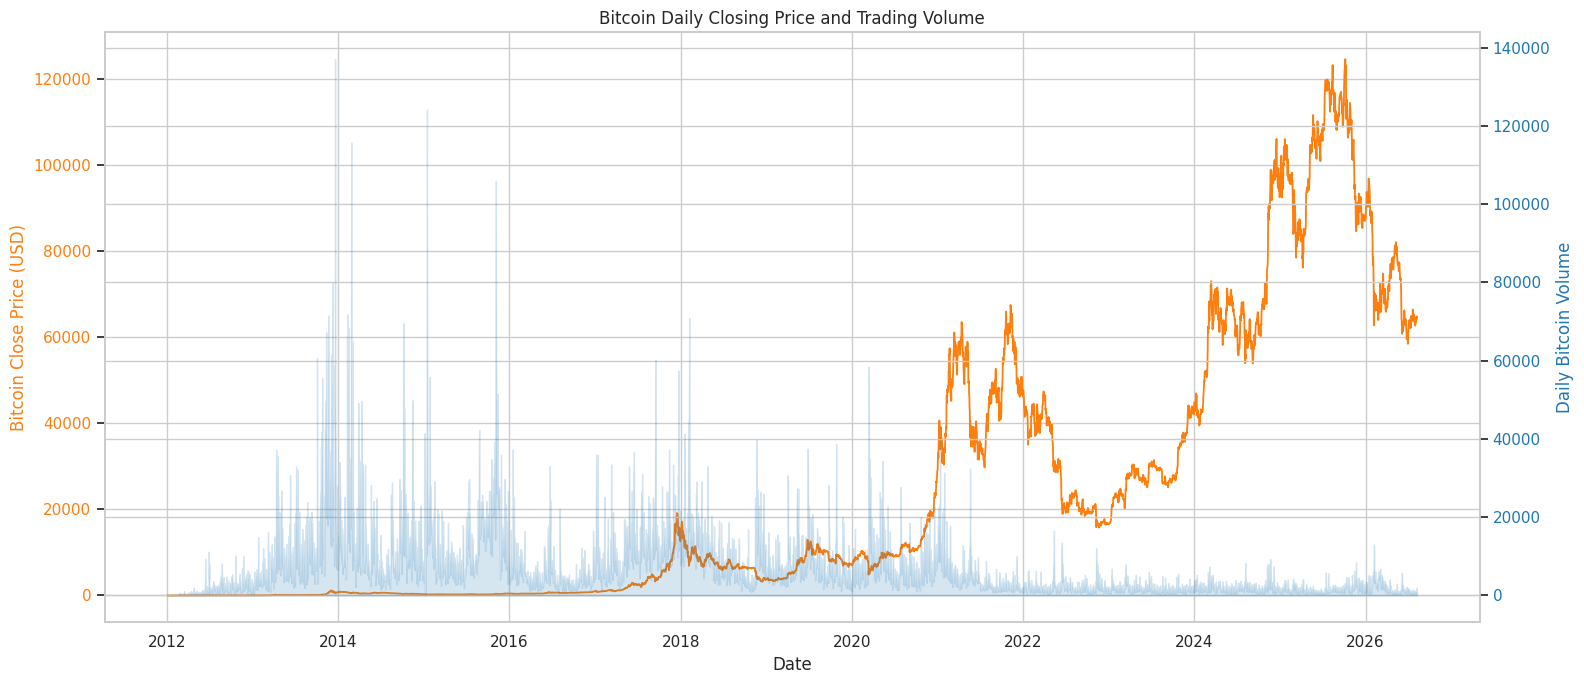

In [ ]:
# Evidence that the data is chronologically organised: plot daily Close and Volume.
daily_pdf = daily_df.orderBy("Date").toPandas()

fig, ax1 = plt.subplots(figsize=(16, 7))
ax1.plot(daily_pdf["Date"], daily_pdf["Close"], color="tab:orange", linewidth=1.3)
ax1.set_xlabel("Date")
ax1.set_ylabel("Bitcoin Close Price (USD)", color="tab:orange")
ax1.tick_params(axis="y", labelcolor="tab:orange")

ax2 = ax1.twinx()
ax2.fill_between(
    daily_pdf["Date"], daily_pdf["Volume"],
    color="tab:blue", alpha=0.18
)
ax2.set_ylabel("Daily Bitcoin Volume", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

plt.title("Bitcoin Daily Closing Price and Trading Volume")
fig.tight_layout()
plt.show()

## 6. Temporal feature engineering with window functions

All feature windows end at the current row. They therefore use only present and historical observations. The only future-looking expression is `lead(Close, 1)`, which creates the label and is never included in the feature vector.

Because this dataset contains one asset, its chronological window is global. In a multi-asset system, use `Window.partitionBy("Symbol").orderBy("Date")` to calculate each asset's features independently.

In [ ]:
time_window = Window.orderBy("Date")
rolling_7 = time_window.rowsBetween(-6, 0)
rolling_14 = time_window.rowsBetween(-13, 0)

features_df = (
    daily_df
    # Historical closing-price lags
    .withColumn("Close_Lag_1", lag("Close", 1).over(time_window))
    .withColumn("Close_Lag_2", lag("Close", 2).over(time_window))
    .withColumn("Close_Lag_3", lag("Close", 3).over(time_window))
    .withColumn("Close_Lag_7", lag("Close", 7).over(time_window))
    .withColumn("Close_Lag_14", lag("Close", 14).over(time_window))

    # Daily return and volume lag
    .withColumn(
        "Daily_Return",
        (col("Close") - col("Close_Lag_1")) / col("Close_Lag_1")
    )
    .withColumn("Return_Lag_1", lag("Daily_Return", 1).over(time_window))
    .withColumn("Volume_Lag_1", lag("Volume", 1).over(time_window))

    # Rolling statistics ending at the current day
    .withColumn("Rolling_Mean_7", avg("Close").over(rolling_7))
    .withColumn("Rolling_Std_7", stddev("Close").over(rolling_7))
    .withColumn("Rolling_Mean_14", avg("Close").over(rolling_14))
    .withColumn("Rolling_Std_14", stddev("Close").over(rolling_14))
    .withColumn("Rolling_Volume_Mean_7", avg("Volume").over(rolling_7))

    # Calendar features and cyclic encodings
    .withColumn("Month", month("Date").cast("double"))
    .withColumn("Day_Of_Week", dayofweek("Date").cast("double"))
    .withColumn("Month_Sin", sin(2 * lit(3.141592653589793) * col("Month") / 12))
    .withColumn("Month_Cos", cos(2 * lit(3.141592653589793) * col("Month") / 12))
    .withColumn("Day_Sin", sin(2 * lit(3.141592653589793) * col("Day_Of_Week") / 7))
    .withColumn("Day_Cos", cos(2 * lit(3.141592653589793) * col("Day_Of_Week") / 7))

    # Forecasting label: the following day's closing price
    .withColumn("Target_Date", lead("Date", 1).over(time_window))
    .withColumn("Target_Next_Close", lead("Close", 1).over(time_window))
    .dropna()
    .orderBy("Date")
).cache()

print(f"Rows available after lag/rolling/target creation: {features_df.count():,}")
features_df.select(
    "Date", "Close", "Close_Lag_1", "Rolling_Mean_7",
    "Rolling_Std_7", "Target_Date", "Target_Next_Close"
).show(15, truncate=False)

Rows available after lag/rolling/target creation: 5,319
+----------+-----+-----------+------------------+-------------------+-----------+-----------------+
|Date      |Close|Close_Lag_1|Rolling_Mean_7    |Rolling_Std_7      |Target_Date|Target_Next_Close|
+----------+-----+-----------+------------------+-------------------+-----------+-----------------+
|2012-01-15|7.15 |6.3        |6.7142857142857135|0.3765570847763167 |2012-01-16 |7.1              |
|2012-01-16|7.1  |7.15       |6.828571428571428 |0.3503535629155485 |2012-01-17 |6.0              |
|2012-01-17|6.0  |7.1        |6.665714285714286 |0.43596089820292916|2012-01-18 |7.1              |
|2012-01-18|7.1  |6.0        |6.680000000000001 |0.4501481237696469 |2012-01-19 |6.22             |
|2012-01-19|6.22 |7.1        |6.638571428571429 |0.4807088020631123 |2012-01-20 |6.95             |
|2012-01-20|6.95 |6.22       |6.688571428571429 |0.494045496266237  |2012-01-21 |6.77             |
|2012-01-21|6.77 |6.95       |6.755714285714

## 7. Chronological train–test split

A random split would allow later market periods to enter the training set and would leak future information. The first 80% of rows are therefore used for training and the final 20% for testing.

In [ ]:
indexed_df = features_df.withColumn(
    "row_number", row_number().over(time_window)
).cache()

total_rows = indexed_df.count()
split_index = int(total_rows * 0.80)

train_df = indexed_df.filter(col("row_number") <= split_index).cache()
test_df = indexed_df.filter(col("row_number") > split_index).cache()

train_range = train_df.agg(
    spark_min("Date").alias("Feature_Start"),
    spark_max("Target_Date").alias("Target_End")
).first()
test_range = test_df.agg(
    spark_min("Date").alias("Feature_Start"),
    spark_max("Target_Date").alias("Target_End")
).first()

print(f"Training rows (past 80%): {train_df.count():,}")
print(f"Training period: {train_range['Feature_Start']} to {train_range['Target_End']}")
print(f"Testing rows (future 20%): {test_df.count():,}")
print(f"Testing period:  {test_range['Feature_Start']} to {test_range['Target_End']}")

Training rows (past 80%): 4,255
Training period: 2012-01-15 to 2023-09-09
Testing rows (future 20%): 1,064
Testing period:  2023-09-09 to 2026-08-08


## 8. Build and train the distributed regression models

Linear Regression uses standardised features because the inputs have very different numeric scales. Tree splits are not scale-sensitive, so Gradient-Boosted Trees use the assembled raw feature vector.

In [ ]:
feature_cols = [
    "Open", "High", "Low", "Close", "Volume", "Weighted_Price",
    "Close_Lag_1", "Close_Lag_2", "Close_Lag_3", "Close_Lag_7", "Close_Lag_14",
    "Daily_Return", "Return_Lag_1", "Volume_Lag_1",
    "Rolling_Mean_7", "Rolling_Std_7",
    "Rolling_Mean_14", "Rolling_Std_14", "Rolling_Volume_Mean_7",
    "Month_Sin", "Month_Cos", "Day_Sin", "Day_Cos"
]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="raw_features",
    handleInvalid="skip"
)

scaler = StandardScaler(
    inputCol="raw_features",
    outputCol="scaled_features",
    withStd=True,
    withMean=True
)

linear_regression = LinearRegression(
    featuresCol="scaled_features",
    labelCol="Target_Next_Close",
    predictionCol="LR_Prediction",
    maxIter=100,
    regParam=0.05,
    elasticNetParam=0.0
)

gradient_boosted_trees = GBTRegressor(
    featuresCol="raw_features",
    labelCol="Target_Next_Close",
    predictionCol="GBT_Prediction",
    maxIter=60,
    maxDepth=5,
    stepSize=0.05,
    seed=42
)

lr_pipeline = Pipeline(stages=[assembler, scaler, linear_regression])
gbt_pipeline = Pipeline(stages=[assembler, gradient_boosted_trees])

print("Feature count:", len(feature_cols))
print("Model pipelines created.")

Feature count: 23
Model pipelines created.


In [ ]:
print("Training Linear Regression...")
lr_model = lr_pipeline.fit(train_df)
lr_predictions = lr_model.transform(test_df).cache()

print("Training Gradient-Boosted Trees...")
gbt_model = gbt_pipeline.fit(train_df)
gbt_predictions = gbt_model.transform(test_df).cache()

print("Both models trained and test predictions generated.")

Training Linear Regression...
Training Gradient-Boosted Trees...
Both models trained and test predictions generated.


## 9. Prediction evidence

The table below presents the forecast date, actual future closing price, and both model predictions. A naive forecast (`tomorrow = today`) is retained as a realistic benchmark.

In [ ]:
prediction_comparison = (
    lr_predictions.select(
        "row_number", "Date", "Target_Date", "Close",
        "Target_Next_Close", "LR_Prediction"
    )
    .join(
        gbt_predictions.select("row_number", "GBT_Prediction"),
        on="row_number",
        how="inner"
    )
    .withColumn("Naive_Prediction", col("Close"))
    .orderBy("Target_Date")
).cache()

print("Sample future-price predictions:")
prediction_comparison.select(
    "Date", "Target_Date", "Close", "Target_Next_Close",
    "LR_Prediction", "GBT_Prediction", "Naive_Prediction"
).show(20, truncate=False)

Sample future-price predictions:
+----------+-----------+-------+-----------------+------------------+------------------+----------------+
|Date      |Target_Date|Close  |Target_Next_Close|LR_Prediction     |GBT_Prediction    |Naive_Prediction|
+----------+-----------+-------+-----------------+------------------+------------------+----------------+
|2023-09-09|2023-09-10 |25899.0|25836.0          |25858.392704745413|24579.244812101082|25899.0         |
|2023-09-10|2023-09-11 |25836.0|25155.0          |25824.059000480564|24799.826207875856|25836.0         |
|2023-09-11|2023-09-12 |25155.0|25844.0          |25131.350003422267|24510.93257855677 |25155.0         |
|2023-09-12|2023-09-13 |25844.0|26226.0          |25683.77271964135 |26436.963344954034|25844.0         |
|2023-09-13|2023-09-14 |26226.0|26529.0          |26097.006144540024|26891.04900321508 |26226.0         |
|2023-09-14|2023-09-15 |26529.0|26607.0          |26426.984799384478|24824.66147465186 |26529.0         |
|2023-09-15|2

## 10. Evaluate RMSE, MAE, and R²

- **RMSE** penalises large forecasting errors more strongly.
- **MAE** is the average absolute error in US dollars and is easier to interpret.
- **R²** measures how much of the variation in future closing prices is explained by the model.
- The naive benchmark predicts that the next closing price will equal the current closing price.

In [ ]:
def evaluate_model(prediction_df, prediction_col, model_name):
    metrics = {"Model": model_name}
    for metric_name, output_name in [
        ("rmse", "RMSE"),
        ("mae", "MAE"),
        ("r2", "R2")
    ]:
        evaluator = RegressionEvaluator(
            labelCol="Target_Next_Close",
            predictionCol=prediction_col,
            metricName=metric_name
        )
        metrics[output_name] = evaluator.evaluate(prediction_df)
    return metrics

results = [
    evaluate_model(
        prediction_comparison, "LR_Prediction", "Linear Regression"
    ),
    evaluate_model(
        prediction_comparison, "GBT_Prediction", "Gradient-Boosted Trees"
    ),
    evaluate_model(
        prediction_comparison, "Naive_Prediction", "Naive: Current Close"
    )
]

results_pdf = pd.DataFrame(results)
results_pdf[["RMSE", "MAE", "R2"]] = results_pdf[["RMSE", "MAE", "R2"]].round(4)
results_pdf = results_pdf.sort_values("RMSE").reset_index(drop=True)

print("Model evaluation results:")
display(results_pdf)

Model evaluation results:


,Model,RMSE,MAE,R2
0,Naive: Current Close,1855.7199,1299.7194,0.9942
1,Linear Regression,1884.7096,1326.7075,0.9940
2,Gradient-Boosted Trees,28858.8478,21167.1809,-0.4124


In [ ]:
# Display model details as further evidence of training.
lr_stage = lr_model.stages[-1]
gbt_stage = gbt_model.stages[-1]

print("Linear Regression intercept:", lr_stage.intercept)
print("Linear Regression iterations:", lr_stage.summary.totalIterations)

importance_pdf = pd.DataFrame({
    "Feature": feature_cols,
    "GBT_Importance": gbt_stage.featureImportances.toArray()
}).sort_values("GBT_Importance", ascending=False)

print("Top 10 GBT feature importances:")
display(importance_pdf.head(10).reset_index(drop=True))

Linear Regression intercept: 10754.601962397179
Linear Regression iterations: 0
Top 10 GBT feature importances:


,Feature,GBT_Importance
0,Close,0.908983
1,High,0.022454
2,Weighted_Price,0.017573
3,Rolling_Std_14,0.004991
4,Month_Cos,0.004767
5,Daily_Return,0.004697
6,Return_Lag_1,0.004248
7,Rolling_Volume_Mean_7,0.004014
8,Volume,0.003850
9,Month_Sin,0.003632


## 11. Visualise forecasts and analyse performance

The final 100 test observations are plotted for clarity. The automatically generated statements compare both trained models with each other and with the naive benchmark.

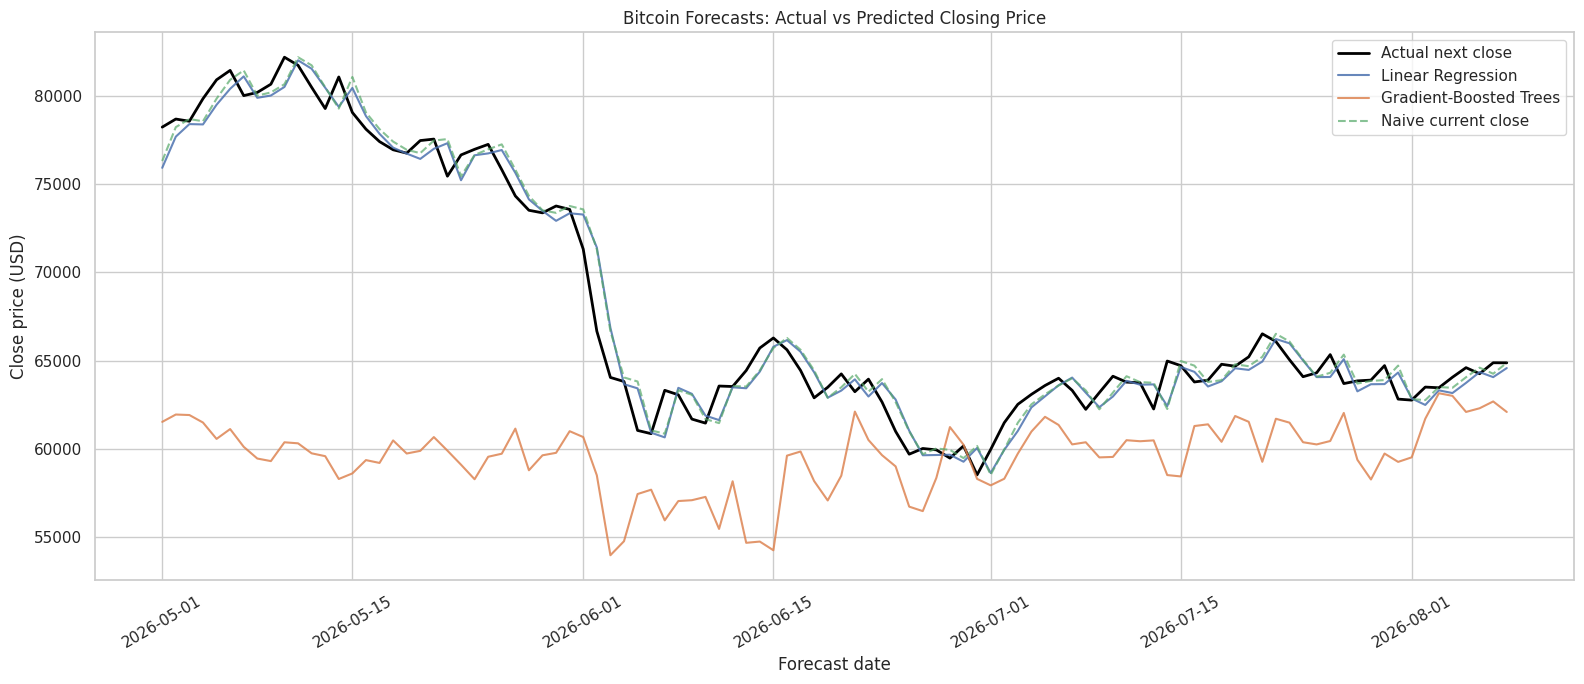

In [ ]:
last_100_pdf = (
    prediction_comparison
    .orderBy(col("Target_Date").desc())
    .limit(100)
    .orderBy("Target_Date")
    .select(
        "Target_Date", "Target_Next_Close",
        "LR_Prediction", "GBT_Prediction", "Naive_Prediction"
    )
    .toPandas()
)

plt.figure(figsize=(16, 7))
plt.plot(
    last_100_pdf["Target_Date"], last_100_pdf["Target_Next_Close"],
    label="Actual next close", color="black", linewidth=2
)
plt.plot(
    last_100_pdf["Target_Date"], last_100_pdf["LR_Prediction"],
    label="Linear Regression", alpha=0.85
)
plt.plot(
    last_100_pdf["Target_Date"], last_100_pdf["GBT_Prediction"],
    label="Gradient-Boosted Trees", alpha=0.85
)
plt.plot(
    last_100_pdf["Target_Date"], last_100_pdf["Naive_Prediction"],
    label="Naive current close", linestyle="--", alpha=0.7
)
plt.title("Bitcoin Forecasts: Actual vs Predicted Closing Price")
plt.xlabel("Forecast date")
plt.ylabel("Close price (USD)")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
trained_results = results_pdf[
    results_pdf["Model"].isin(["Linear Regression", "Gradient-Boosted Trees"])
].sort_values("RMSE")
best_trained = trained_results.iloc[0]
naive_result = results_pdf[results_pdf["Model"] == "Naive: Current Close"].iloc[0]

rmse_change = (
    (naive_result["RMSE"] - best_trained["RMSE"])
    / naive_result["RMSE"] * 100
)

print("AUTOMATIC PERFORMANCE ANALYSIS")
print("-" * 40)
print(
    f"The better trained model by RMSE is {best_trained['Model']} "
    f"(RMSE = ${best_trained['RMSE']:,.2f}, MAE = ${best_trained['MAE']:,.2f})."
)

if rmse_change > 0:
    print(
        f"It improves RMSE by {rmse_change:.2f}% compared with the naive "
        "current-close forecast."
    )
else:
    print(
        f"Its RMSE is {abs(rmse_change):.2f}% worse than the naive forecast. "
        "This shows that Bitcoin's next-day price level is difficult to beat "
        "with these historical features alone."
    )

if best_trained["Model"] == "Gradient-Boosted Trees":
    print(
        "GBT performed better, suggesting nonlinear relationships and feature "
        "interactions were useful during this test period."
    )
else:
    print(
        "Linear Regression performed better, suggesting that the dominant "
        "next-day price relationship was approximately linear during this period."
    )

print(
    "The chronological holdout makes these metrics more realistic than a random "
    "split because every test observation occurs after the training period."
)

AUTOMATIC PERFORMANCE ANALYSIS
----------------------------------------
The better trained model by RMSE is Linear Regression (RMSE = $1,884.71, MAE = $1,326.71).
Its RMSE is 1.56% worse than the naive forecast. This shows that Bitcoin's next-day price level is difficult to beat with these historical features alone.
Linear Regression performed better, suggesting that the dominant next-day price relationship was approximately linear during this period.
The chronological holdout makes these metrics more realistic than a random split because every test observation occurs after the training period.


## 12. Save the prediction evidence

The test-set predictions are saved as a CSV in the Colab runtime. You can download this output from Colab's Files panel if you want to include it as additional submission evidence.

In [ ]:
OUTPUT_FILE = "/content/bitcoin_forecast_predictions.csv"
prediction_comparison.select(
    "Date", "Target_Date", "Close", "Target_Next_Close",
    "LR_Prediction", "GBT_Prediction", "Naive_Prediction"
).orderBy("Target_Date").toPandas().to_csv(OUTPUT_FILE, index=False)

print("Predictions saved to:", OUTPUT_FILE)
print("Use the Colab Files panel to download it if required.")

Predictions saved to: /content/bitcoin_forecast_predictions.csv
Use the Colab Files panel to download it if required.


## 13. Conclusion

This notebook demonstrates a complete time-aware PySpark forecasting pipeline. The large raw Bitcoin CSV is loaded and cleaned with Spark, one-minute data is distributedly aggregated to daily OHLCV observations, lag and rolling features are produced with ordered windows, and the future closing price becomes the supervised label. A chronological split protects the evaluation from future-to-past leakage. Linear Regression and Gradient-Boosted Trees are then compared using RMSE and MAE, with a naive current-close forecast providing an important financial benchmark.

Forecasting financial prices remains difficult because market behaviour changes over time and historical OHLCV data does not contain all market-moving information. Possible future improvements include walk-forward validation, hyperparameter tuning performed only on the training period, return-based targets, sentiment variables, macroeconomic features, and additional technical indicators.

In [ ]:
# Stop spark session
spark.stop()
print("Spark session stopped.")

Spark session stopped.
